## Imports

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../../../')

In [2]:
import pickle
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from pathlib import Path

from scipy.signal import correlate

In [ ]:
# ── Parameters — edit these to select what to plot ───────────────────────────
RESULTS_DIR = Path('/data/equake_results/lagged_kin_dec_all_pcs/')
SESSION     = 'M078_2025_08_06_15_00'
AREA        = 'MOp'
KEYPOINT    = 'left_elbow'

# Visualisation windows
BASELINE_S  = (-0.8, -0.3)
SPAGHETTI_S = (-0.1,  0.3)

# List available files
files = sorted(RESULTS_DIR.glob('lagged_dec_*.pkl'))
print(f'Found {len(files)} result files:')
for f in files:
    print(f'  {f.name}')


Found 9 result files:
  lagged_dec_MOp_M061_2025_03_04_10_00.pkl
  lagged_dec_MOp_M061_2025_03_05_14_00.pkl
  lagged_dec_MOp_M061_2025_03_06_14_00.pkl
  lagged_dec_MOp_M062_2025_03_20_14_00.pkl
  lagged_dec_MOp_M062_2025_03_21_14_00.pkl
  lagged_dec_MOp_M063_2025_03_13_14_00.pkl
  lagged_dec_MOp_M063_2025_03_14_15_30.pkl
  lagged_dec_MOp_M078_2025_08_06_15_00.pkl
  lagged_dec_MOp_M086_2025_12_10_15_00.pkl


In [4]:
# ── Load results ──────────────────────────────────────────────────────────────
pkl_path = RESULTS_DIR / f'lagged_dec_{AREA}_{SESSION}.pkl'
with open(pkl_path, 'rb') as f:
    _raw = pickle.load(f)

LAG_MASK = (-200, 201)
# ── Read metadata (saved by script) or fall back to inferring from data ───────
if '_meta' in _raw:
    _meta        = _raw.pop('_meta')
    BIN_SIZE     = _meta['bin_size']
    WINDOW_S     = _meta['window_s']
    lags_ms      = _meta['lags_s'] * 1000        # stored in seconds → convert to ms
    time_step_s  = _meta['time_step_s']
    results_session = _raw
    print(f'Metadata loaded from pkl:')
    print(f'  bin_size={BIN_SIZE*1000:.0f} ms  window={WINDOW_S*1000:.0f} ms  '
          f'step={time_step_s*1000:.0f} ms  '
          f'lags={lags_ms[0]:.0f}→{lags_ms[-1]:.0f} ms  ({len(lags_ms)} lags)')
else:
    # Legacy pkl — infer what we can from the data shape
    results_session = _raw
    BIN_SIZE    = 0.01
    WINDOW_S    = 0.20
    n_lags      = next(iter(next(iter(results_session.values())).values())).shape[0]
    lags_ms     = np.arange(n_lags) * BIN_SIZE * 1000   # assume lags start at 0
    time_step_s = None
    print('WARNING: no _meta key found — re-run the script to save metadata.')

results  = results_session[KEYPOINT]
all_t    = np.array(sorted(results.keys()))
t_0_idx  = np.argmin(np.abs(lags_ms))

print(f'Loaded   : {pkl_path.name}')
print(f'Keypoints: {list(results_session.keys())}')
print(f'Time bins: {all_t[0]:.2f} → {all_t[-1]:.2f} s  ({len(all_t)} bins)')

Metadata loaded from pkl:
  bin_size=10 ms  window=200 ms  step=30 ms  lags=-250→250 ms  (51 lags)
Loaded   : lagged_dec_MOp_M078_2025_08_06_15_00.pkl
Keypoints: ['left_elbow']
Time bins: -0.80 → 1.27 s  (70 bins)


In [5]:
def _xcorr(curve, baseline):
    c  = curve    / (curve.max()    + 1e-12)
    b  = baseline / (baseline.max() + 1e-12)
    return correlate(c, b, mode='same')

In [6]:
_res      = _raw[KEYPOINT]
_t        = np.array(sorted(_res.keys()))
_bl_mask = (_t >= BASELINE_S[0]) & (_t < BASELINE_S[1])
_bl_mean = np.array([_res[ti].mean(-1) for ti in _t[_bl_mask]]).mean(0)
lag_mask = (lags_ms >= LAG_MASK[0]) & (lags_ms <= LAG_MASK[1])

NameError: name 'test_curve' is not defined

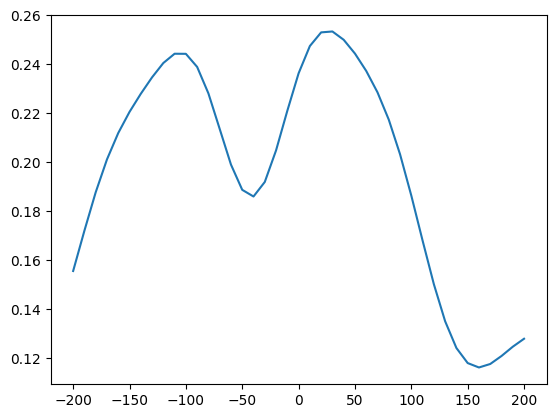

In [7]:
plt.plot(lags_ms[lag_mask], _bl_mean[lag_mask])
plt.plot(lags_ms[lag_mask], np.squeeze(test_curve)[lag_mask])

In [8]:
def _xcorr_drift(curve, baseline, lags):
    c  = curve    #/ (curve.max()    + 1e-12)
    b  = baseline #/ (baseline.max() + 1e-12)
    return correlate(c, b, mode='same').argmax()

In [9]:
curves = np.array([_xcorr(_res[ti][lag_mask].mean(-1), _bl_mean[lag_mask]) for ti in _t])
drift = np.array([_xcorr_drift(_res[ti][lag_mask].mean(-1), _bl_mean[lag_mask], lags_ms[lag_mask]) for ti in _t])

In [10]:
curves.shape

(70, 41)

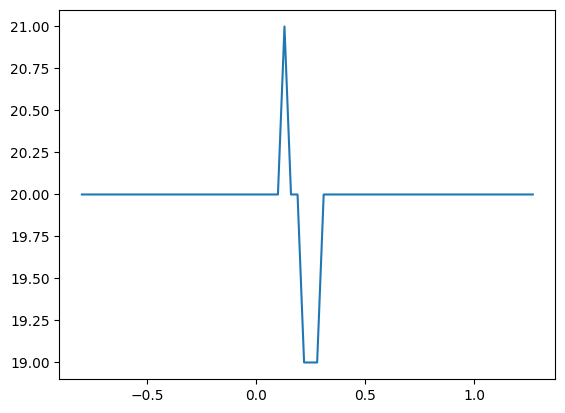

In [11]:
plt.plot(_t, drift)

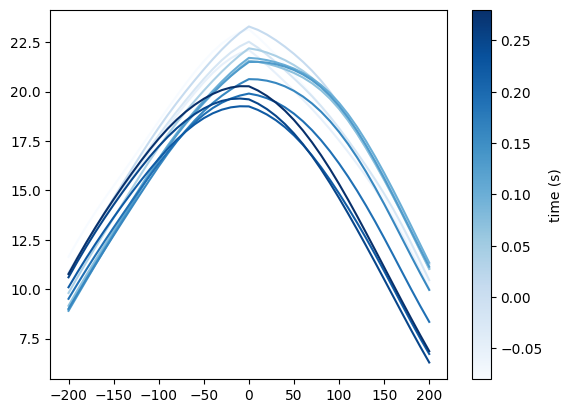

Plotted 13 curves from -0.08 to 0.28 s


In [12]:
sp_mask = (_t >= SPAGHETTI_S[0]) & (_t <= SPAGHETTI_S[1])
sp_curves = curves[sp_mask]
sp_t = _t[sp_mask]

cmap = plt.cm.Blues
colors = cmap(np.linspace(0, 1, len(sp_t)))

fig, ax = plt.subplots()
for curve, color in zip(sp_curves, colors):
    ax.plot(lags_ms[lag_mask], curve, color=color)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=mpl.colors.Normalize(vmin=sp_t[0], vmax=sp_t[-1]))
sm.set_array([])
fig.colorbar(sm, ax=ax, label='time (s)')
plt.show()
print(f'Plotted {len(sp_t)} curves from {sp_t[0]:.2f} to {sp_t[-1]:.2f} s')

In [15]:
def _compute_drift(curve, baseline, lags):
    from scipy.signal import correlate
    c  = curve    / (curve.max()    + 1e-12)
    b  = baseline / (baseline.max() + 1e-12)
    xc = correlate(c, b, mode='full')
    step = lags[1] - lags[0]
    pk   = xc.argmax()
    if 0 < pk < len(xc) - 1:
        y0, y1, y2 = xc[pk - 1], xc[pk], xc[pk + 1]
        delta = 0.5 * (y0 - y2) / (y0 - 2 * y1 + y2 + 1e-12)
        return (pk + delta) * step - (len(lags) - 1) * step
    return (pk - (len(lags) - 1)) * step

In [16]:
drift_interp = np.array([_compute_drift(_res[ti][lag_mask].mean(-1), _bl_mean[lag_mask], lags_ms[lag_mask]) for ti in _t])

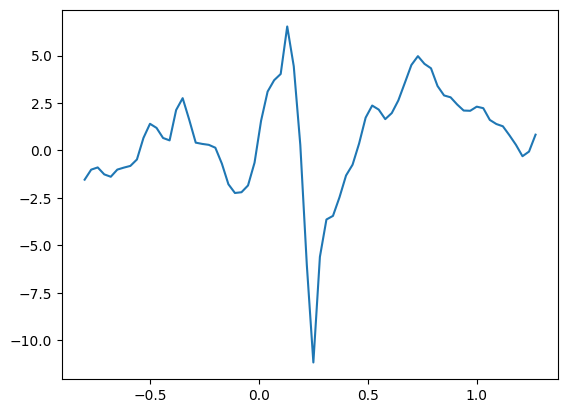

In [17]:
plt.plot(_t, drift_interp)

In [70]:
from scipy.stats import sem

SESSIONS_ALL = [
    'M061_2025_03_04_10_00',
    'M061_2025_03_05_14_00',
    'M061_2025_03_06_14_00',
    'M062_2025_03_20_14_00',
    'M062_2025_03_21_14_00',
    'M063_2025_03_13_14_00',
    'M063_2025_03_14_15_30',
    'M078_2025_08_06_15_00',
    'M086_2025_12_10_15_00',
]

LEFT_FORELIMBS = ['left_elbow']

# group sessions by animal (first 4 chars = animal ID)
animals = {}
for sess in SESSIONS_ALL:
    animals.setdefault(sess[:4], []).append(sess)

# ── compute drift and xcorr curves per session ───────────────────────────────
session_drifts = {}   # sess → 1-D drift array (n_times,)
session_curves = {}   # sess → 2-D xcorr array (n_times, n_lags)
t_ref   = None
lags_ref = None

for sess in SESSIONS_ALL:
    pkl_path = RESULTS_DIR / f'lagged_dec_{AREA}_{sess}.pkl'
    with open(pkl_path, 'rb') as fh:
        raw = pickle.load(fh)

    if '_meta' in raw:
        meta      = raw.pop('_meta')
        lags_ms_s = meta['lags_s'] * 1000
    else:
        lags_ms_s = lags_ms

    lm      = (lags_ms_s >= LAG_MASK[0]) & (lags_ms_s <= LAG_MASK[1])
    lags_s  = lags_ms_s[lm]
    if lags_ref is None:
        lags_ref = lags_s

    kp_drifts = []
    kp_curves = []
    for kp in LEFT_FORELIMBS:
        if kp not in raw:
            continue
        res = raw[kp]
        t   = np.array(sorted(res.keys()))
        if t_ref is None:
            t_ref = t

        bl_mask = (t >= BASELINE_S[0]) & (t < BASELINE_S[1])
        bl_mean = np.array([res[ti].mean(-1)[lm] for ti in t[bl_mask]]).mean(0)

        drift  = np.array([_compute_drift(res[ti].mean(-1)[lm], bl_mean, lags_s)
                           for ti in t])
        curves_kp = np.array([_xcorr(res[ti].mean(-1)[lm], bl_mean)
                               for ti in t])
        kp_drifts.append(drift)
        kp_curves.append(curves_kp)

    session_drifts[sess] = np.mean(kp_drifts, axis=0)
    session_curves[sess] = np.mean(kp_curves, axis=0)   # (n_times, n_lags)
    t0_val = session_drifts[sess][np.argmin(np.abs(t_ref))]
    print(f'{sess}  drift at t=0 → {t0_val:.1f} ms')

# ── average within animal, then across animals ───────────────────────────────
animal_drifts = {
    animal: np.mean([session_drifts[s] for s in sessions], axis=0)
    for animal, sessions in animals.items()
}
animal_curves = {
    animal: np.mean([session_curves[s] for s in sessions], axis=0)
    for animal, sessions in animals.items()
}

animal_arr    = np.array(list(animal_drifts.values()))
grand_mean    = animal_arr.mean(0)
grand_sem     = sem(animal_arr, axis=0)

grand_curves  = np.mean(list(animal_curves.values()), axis=0)   # (n_times, n_lags)

print(f'\nAnimals: {list(animal_drifts.keys())}')
print(f'Grand mean drift at t=0: {grand_mean[np.argmin(np.abs(t_ref))]:.2f} ms')

M061_2025_03_04_10_00  drift at t=0 → 2.5 ms
M061_2025_03_05_14_00  drift at t=0 → 2.4 ms
M061_2025_03_06_14_00  drift at t=0 → 8.8 ms
M062_2025_03_20_14_00  drift at t=0 → -1.7 ms
M062_2025_03_21_14_00  drift at t=0 → 1.3 ms
M063_2025_03_13_14_00  drift at t=0 → -28.1 ms
M063_2025_03_14_15_30  drift at t=0 → -2.0 ms
M078_2025_08_06_15_00  drift at t=0 → 1.6 ms
M086_2025_12_10_15_00  drift at t=0 → 1.0 ms

Animals: ['M061', 'M062', 'M063', 'M078', 'M086']
Grand mean drift at t=0: -1.60 ms


Grand mean drift at t=0: -1.60 ms


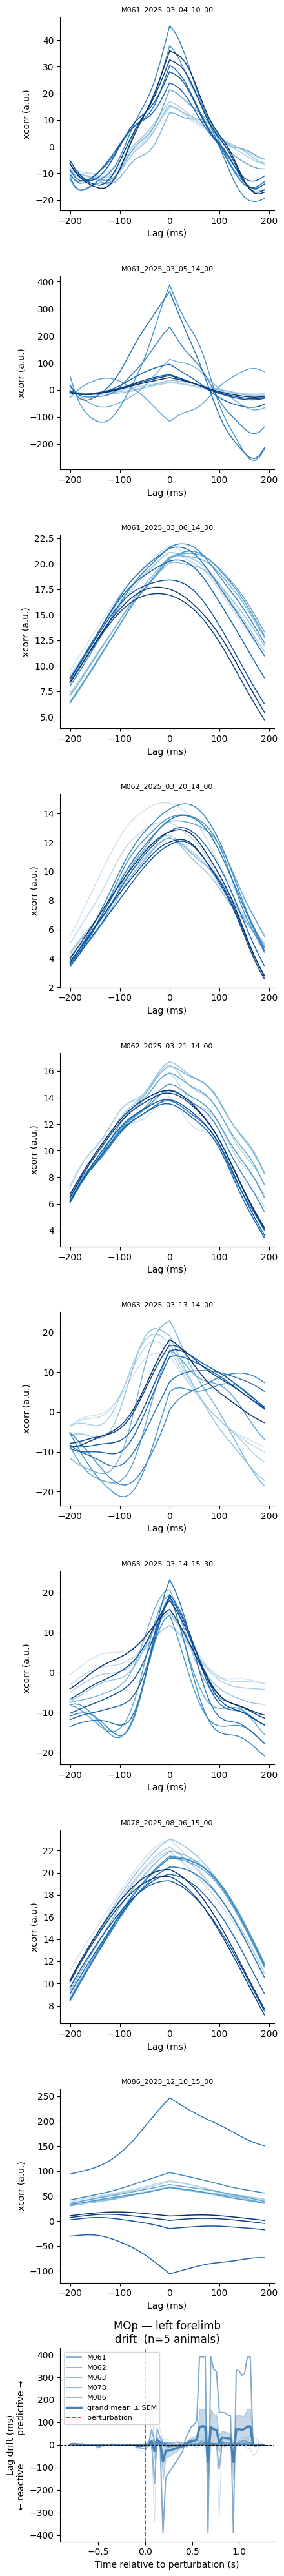

In [74]:
n_sess = len(SESSIONS_ALL)
fig, axes = plt.subplots(n_sess + 1, 1, figsize=(4.5, 4 * (n_sess + 1)))

cmap = plt.cm.Blues
sp_mask = (t_ref >= SPAGHETTI_S[0]) & (t_ref <= SPAGHETTI_S[1])
sp_t    = t_ref[sp_mask]
colors  = cmap(np.linspace(0.2, 1.0, len(sp_t)))

# ── one xcorr spaghetti per session ──────────────────────────────────────────
for ax, sess in zip(axes[:-1], SESSIONS_ALL):
    sp_curves = session_curves[sess][sp_mask]
    for curve, color in zip(sp_curves, colors):
        ax.plot(lags_ref, curve, color=color, lw=1.1)
    ax.set_xlabel('Lag (ms)')
    ax.set_ylabel('xcorr (a.u.)')
    ax.set_title(sess, fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)

sm = plt.cm.ScalarMappable(cmap=cmap,
                           norm=mpl.colors.Normalize(vmin=sp_t[0], vmax=sp_t[-1]))
sm.set_array([])
# fig.colorbar(sm, ax=axes[:-1].tolist(), label='time (s)', shrink=0.8)

# ── right: drift timecourse ───────────────────────────────────────────────────
ax_dr = axes[-1]
for sess, drift in session_drifts.items():
    ax_dr.plot(t_ref, drift, color='steelblue', lw=0.8, alpha=0.25)

for animal, drift in animal_drifts.items():
    ax_dr.plot(t_ref, drift, color='steelblue', lw=1.5, alpha=0.6, label=animal)

ax_dr.fill_between(t_ref, grand_mean - grand_sem, grand_mean + grand_sem,
                   color='steelblue', alpha=0.3)
ax_dr.plot(t_ref, grand_mean, color='steelblue', lw=2.5, label='grand mean ± SEM')
ax_dr.axhline(0, color='k', lw=0.8, linestyle='dashed')
ax_dr.axvline(0, color='r', lw=1.2, linestyle='dashed', label='perturbation')
ax_dr.set_xlabel('Time relative to perturbation (s)')
ax_dr.set_ylabel('Lag drift (ms)\n← reactive          predictive →')
ax_dr.set_title(f'{AREA} — left forelimb\ndrift  (n={len(animal_drifts)} animals)')
ax_dr.spines[['top', 'right']].set_visible(False)
ax_dr.legend(fontsize=8)

plt.tight_layout()
print(f'Grand mean drift at t=0: {grand_mean[np.argmin(np.abs(t_ref))]:.2f} ms')